# Model Interpretation - Graduate Admissions

**Author:** SCO

**Date:** 2026-08-20

**Issue:** #7 - Model Interpretation

This notebook interprets the fixed `LinearRegression` model selected in Issue #6.
It loads the complete serialized preprocessing and model Pipeline, reports the
established evaluation results, analyzes coefficient scales, describes
multicollinearity and computes post-selection permutation importance.

No model selection, tuning, feature selection, retraining or model modification is
performed here. Interpretations describe predictive associations, not causal effects.

## Import libraries

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.validation import check_is_fitted

RANDOM_STATE = 42
TARGET = "Chance of Admit"
NUMERIC_FEATURES = ["GRE Score", "TOEFL Score", "CGPA"]
ORDINAL_FEATURES = ["University Rating", "SOP", "LOR"]
BINARY_FEATURES = ["Research"]
FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + BINARY_FEATURES
EXPECTED_FEATURE_NAMES = [
    "numeric__GRE Score",
    "numeric__TOEFL Score",
    "numeric__CGPA",
    "ordinal__University Rating",
    "ordinal__SOP",
    "ordinal__LOR",
    "binary__Research",
]

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

Python: 3.12.13
pandas: 3.0.5
NumPy: 2.5.2
scikit-learn: 1.9.0
joblib: 1.5.3


## Load data and the fixed model artifact

The repository root is located from the notebook working directory. The Parquet
dataset is read without modifying either the intermediate data or RAW. The model
artifact is loaded read-only from the path produced by Issue #6.

The official evaluation metrics are loaded from
`data/08_reporting/training_metrics.json`, the report persisted by the training
pipeline. No CV is rerun here.


In [2]:
def find_repo_root(start: Path) -> Path:
    """Locate the repository root by searching for pyproject.toml."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find the repository root.")


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "02_intermediate" / "Admission_Predict.parquet"
MODEL_PATH = ROOT / "models" / "05_model_selection_pipeline.joblib"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model artifact not found: {MODEL_PATH}")

REPORT_PATH = ROOT / "data" / "08_reporting" / "training_metrics.json"
if not REPORT_PATH.exists():
    raise FileNotFoundError(f"Metrics report not found: {REPORT_PATH}")

with REPORT_PATH.open(encoding="utf-8") as handle:
    report_metrics = json.load(handle)

required_report_keys = {
    "model": (),
    "rows": ("train", "test"),
    "train": ("rmse", "mae", "r2"),
    "cv": ("rmse_mean", "mae_mean", "r2_mean", "rmse_std"),
    "test": ("rmse", "mae", "r2"),
}
missing_report_keys = [
    f"{section}.{key}"
    for section, keys in required_report_keys.items()
    for key in keys
    if section not in report_metrics or key not in report_metrics[section]
]
if missing_report_keys:
    raise KeyError(f"Metrics report is missing required keys: {missing_report_keys}")

admission_df = pd.read_parquet(DATA_PATH)
expected_columns = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    TARGET,
]
assert list(admission_df.columns) == expected_columns
assert admission_df[TARGET].notna().all()
assert admission_df[TARGET].between(0.0, 1.0).all()

final_pipeline = joblib.load(MODEL_PATH)
assert isinstance(final_pipeline, Pipeline)
assert list(final_pipeline.named_steps) == ["preprocessor", "model"]
assert isinstance(final_pipeline.named_steps["preprocessor"], ColumnTransformer)
assert isinstance(final_pipeline.named_steps["model"], LinearRegression)

print("Metrics report loaded from:", REPORT_PATH.relative_to(ROOT))
print("Dataset loaded from:", DATA_PATH.relative_to(ROOT))
print("Model loaded from:", MODEL_PATH.relative_to(ROOT))
print(f"Original dataset shape: {admission_df.shape}")

Metrics report loaded from: data/08_reporting/training_metrics.json
Dataset loaded from: data/02_intermediate/Admission_Predict.parquet
Model loaded from: models/05_model_selection_pipeline.joblib
Original dataset shape: (623, 8)


## Data preparation and artifact verification

The split reproduces Issue #6 only to evaluate the already fitted artifact.
Exact duplicates are removed in memory before the split. No transformation is
fitted in this notebook. All preprocessing used below comes from the loaded
Pipeline.

### Leakage and scope controls

- The Test set is not used for model selection, tuning, comparison or modification.
- Train and Test predictions use the loaded fixed Pipeline directly.
- Outer CV values come from the official `training_metrics.json` report and are not recreated by CV here.
- VIF is descriptive and cannot drive feature removal or model changes.
- Permutation importance is a post-selection Test diagnostic only.
- The serialized artifact and all data files remain read-only.

In [3]:
initial_rows = len(admission_df)
duplicate_rows = int(admission_df.duplicated().sum())
unique_df = admission_df.drop_duplicates().reset_index(drop=True)

X = unique_df[FEATURES]
y = unique_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

assert (initial_rows, duplicate_rows, len(unique_df)) == (623, 152, 471)
assert (len(X_train), len(X_test)) == (376, 95)
assert set(X_train.index).isdisjoint(set(X_test.index))

preprocessor = final_pipeline.named_steps["preprocessor"]
final_estimator = final_pipeline.named_steps["model"]
check_is_fitted(preprocessor)
check_is_fitted(final_estimator)
feature_names = list(preprocessor.get_feature_names_out())
assert feature_names == EXPECTED_FEATURE_NAMES
assert final_estimator.coef_.shape == (len(feature_names),)

# The report must describe the same model and the same split reproduced here.
assert report_metrics["model"] == final_estimator.__class__.__name__
assert report_metrics["rows"] == {"train": len(X_train), "test": len(X_test)}


def calculate_metrics(y_true: pd.Series, predictions: np.ndarray) -> dict[str, float]:
    """Return the three project metrics in positive, human-readable form."""
    return {
        "RMSE": root_mean_squared_error(y_true, predictions),
        "MAE": mean_absolute_error(y_true, predictions),
        "R2": r2_score(y_true, predictions),
    }


train_predictions = final_pipeline.predict(X_train)
test_predictions = final_pipeline.predict(X_test)
local_train_metrics = calculate_metrics(y_train, train_predictions)
local_test_metrics = calculate_metrics(y_test, test_predictions)

# Official evaluation values come from the training pipeline report.
reported_train_metrics = {
    "RMSE": report_metrics["train"]["rmse"],
    "MAE": report_metrics["train"]["mae"],
    "R2": report_metrics["train"]["r2"],
}
reported_test_metrics = {
    "RMSE": report_metrics["test"]["rmse"],
    "MAE": report_metrics["test"]["mae"],
    "R2": report_metrics["test"]["r2"],
}
outer_cv_metrics = {
    "RMSE": report_metrics["cv"]["rmse_mean"],
    "MAE": report_metrics["cv"]["mae_mean"],
    "R2": report_metrics["cv"]["r2_mean"],
}
outer_cv_rmse_std = report_metrics["cv"]["rmse_std"]

# The loaded artifact must reproduce the reported Train and Test metrics.
for metric, value in reported_train_metrics.items():
    assert np.isclose(local_train_metrics[metric], value, atol=1e-5)
for metric, value in reported_test_metrics.items():
    assert np.isclose(local_test_metrics[metric], value, atol=1e-5)

metrics_df = pd.DataFrame(
    [reported_train_metrics, outer_cv_metrics, reported_test_metrics],
    index=["Train (reported)", "Outer CV (reported)", "Test (reported)"],
)
metrics_df.index.name = "Evaluation set"

print(f"Initial rows: {initial_rows}")
print(f"Exact duplicates removed in memory: {duplicate_rows}")
print(f"Unique rows: {len(unique_df)}")
print(f"Feature names from fitted preprocessor: {feature_names}")
print(f"Reported Outer CV RMSE std: {outer_cv_rmse_std:.6f}")
print("All evaluation metrics come from data/08_reporting/training_metrics.json.")
display(metrics_df.round(6))

Initial rows: 623
Exact duplicates removed in memory: 152
Unique rows: 471
Feature names from fitted preprocessor: ['numeric__GRE Score', 'numeric__TOEFL Score', 'numeric__CGPA', 'ordinal__University Rating', 'ordinal__SOP', 'ordinal__LOR', 'binary__Research']
Reported Outer CV RMSE std: 0.007349
All evaluation metrics come from data/08_reporting/training_metrics.json.


,RMSE,MAE,R2
Evaluation set,,,
Train (reported),0.062440,0.045083,0.807426
Outer CV (reported),0.064463,0.046825,0.786251
Test (reported),0.068500,0.051192,0.787195


## Analysis of results and conclusions

### Evaluation provenance

Train, Outer CV and Test metrics shown above come from the official training
pipeline report `data/08_reporting/training_metrics.json`: five outer folds,
RMSE mean, RMSE standard deviation, MAE mean and R2 mean. Train and Test metrics
are also recalculated locally from the loaded fixed Pipeline and asserted to
match the reported values. No CV is rerun here because model selection is complete.

### Coefficients and preprocessing scale

The six numeric and ordinal outputs are standardized by the fitted preprocessor.
Their coefficients therefore describe the expected target change for a one fitted
training standard deviation increase, holding the other transformed features
constant. The ordinal variables are interpreted after ordinal encoding and scaling.

`Research` is imputed but not scaled. Its coefficient is therefore interpreted
separately as the modeled difference between the binary values 0 and 1, conditional
on the remaining transformed features. It is not ranked together with the six
standardized coefficient magnitudes. All of these are predictive associations,
not causal effects.

Standardized-feature coefficient ranking; Research is excluded by design:


,Standardized rank,Transformed feature,Raw feature,Coefficient,Absolute coefficient,Fitted scaler scale,Interpretation unit,Raw-unit slope
0,1,numeric__CGPA,CGPA,0.069831,0.069831,0.589926,target units per fitted training standard devi...,0.118373
1,2,numeric__TOEFL Score,TOEFL Score,0.022785,0.022785,6.086189,target units per fitted training standard devi...,0.003744
2,3,numeric__GRE Score,GRE Score,0.021420,0.021420,11.340475,target units per fitted training standard devi...,0.001889
3,4,ordinal__LOR,LOR,0.017805,0.017805,1.798462,target units per fitted training standard devi...,0.009900
4,5,ordinal__SOP,SOP,-0.000155,0.000155,2.011635,target units per fitted training standard devi...,-0.000077
5,6,ordinal__University Rating,University Rating,0.000045,0.000045,1.153259,target units per fitted training standard devi...,0.000039


Research coefficient, interpreted separately:


,Transformed feature,Raw feature,Coefficient,Absolute coefficient,Fitted scaler scale,Interpretation unit,Raw-unit slope
6,binary__Research,Research,0.024351,0.024351,NaN,target units for Research 0 to 1 contrast,0.024351


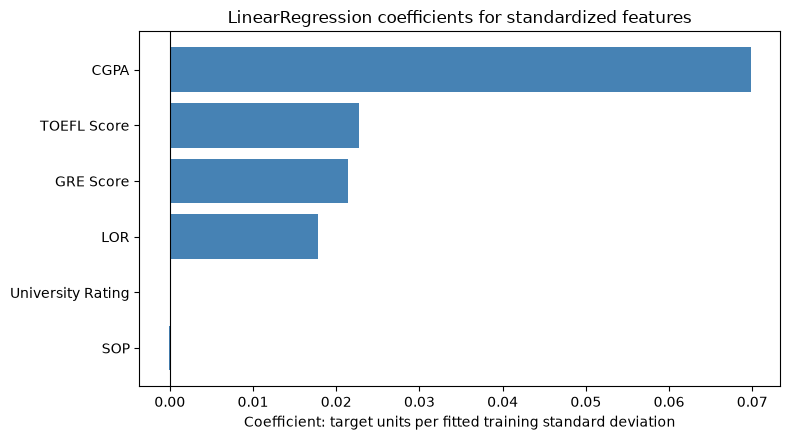

In [4]:
fitted_transformers = {
    name: (transformer, columns) for name, transformer, columns in preprocessor.transformers_
}

coefficient_rows = []
for feature_name, coefficient in zip(feature_names, final_estimator.coef_, strict=True):
    branch, raw_feature = feature_name.split("__", maxsplit=1)
    scale = np.nan
    if branch in {"numeric", "ordinal"}:
        transformer, columns = fitted_transformers[branch]
        scaler = transformer.named_steps["scaler"]
        scale = float(scaler.scale_[list(columns).index(raw_feature)])
        unit = "target units per fitted training standard deviation"
    else:
        unit = "target units for Research 0 to 1 contrast"
    coefficient_rows.append(
        {
            "Transformed feature": feature_name,
            "Raw feature": raw_feature,
            "Coefficient": coefficient,
            "Absolute coefficient": abs(coefficient),
            "Fitted scaler scale": scale,
            "Interpretation unit": unit,
            "Raw-unit slope": coefficient / scale if not np.isnan(scale) else coefficient,
        }
    )

coefficients_df = pd.DataFrame(coefficient_rows)
scaled_coefficients_df = (
    coefficients_df[coefficients_df["Raw feature"] != "Research"]
    .sort_values("Absolute coefficient", ascending=False)
    .reset_index(drop=True)
)
scaled_coefficients_df.insert(0, "Standardized rank", scaled_coefficients_df.index + 1)
research_coefficient_df = coefficients_df[coefficients_df["Raw feature"] == "Research"]

print("Standardized-feature coefficient ranking; Research is excluded by design:")
display(scaled_coefficients_df.round(6))
print("Research coefficient, interpreted separately:")
display(research_coefficient_df.round(6))

fig, ax = plt.subplots(figsize=(8, 4.5))
ordered = scaled_coefficients_df.sort_values("Coefficient")
ax.barh(ordered["Raw feature"], ordered["Coefficient"], color="steelblue")
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient: target units per fitted training standard deviation")
ax.set_title("LinearRegression coefficients for standardized features")
fig.tight_layout()
plt.show()

### Multicollinearity and VIF

VIF is computed on the transformed training features using the fitted preprocessor.
Scaling does not remove linear dependence, and the diagnostic uses no Test rows.
The auxiliary regressions are descriptive only: they do not select features, tune
the estimator or modify the serialized Pipeline. Conventional VIF reference values
are treated as warning guides rather than automatic decision rules.

The previous EDA identified strong redundancy among GRE, TOEFL and CGPA, together
with notable association among SOP, LOR and University Rating. This can make
conditional LinearRegression coefficients unstable and can distribute permutation
importance across correlated predictors.

Training-only VIF values:


,Feature,Auxiliary R2,VIF
0,numeric__CGPA,0.8136,5.3643
1,numeric__TOEFL Score,0.7842,4.6335
2,numeric__GRE Score,0.7768,4.4795
3,ordinal__SOP,0.6660,2.9936
4,ordinal__University Rating,0.6635,2.9721
5,ordinal__LOR,0.5764,2.3606
6,binary__Research,0.3406,1.5165


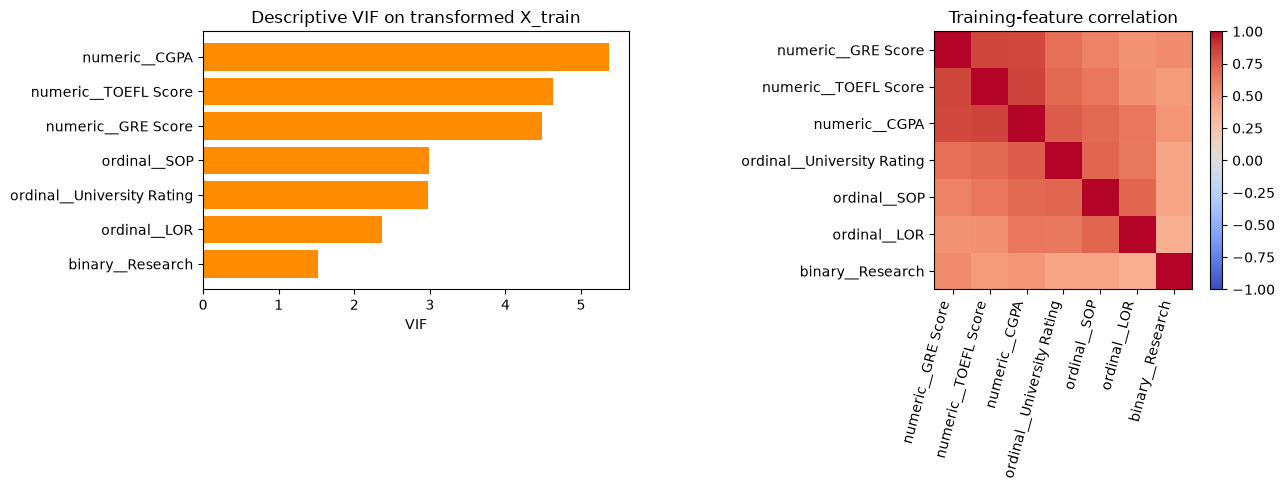

In [5]:
X_train_transformed = np.asarray(preprocessor.transform(X_train), dtype=float)
transformed_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

vif_rows = []
for feature_index, feature_name in enumerate(feature_names):
    response = X_train_transformed[:, feature_index]
    predictors = np.delete(X_train_transformed, feature_index, axis=1)
    auxiliary_model = LinearRegression().fit(predictors, response)
    auxiliary_r2 = auxiliary_model.score(predictors, response)
    vif = np.inf if np.isclose(auxiliary_r2, 1.0) else 1.0 / (1.0 - auxiliary_r2)
    vif_rows.append({"Feature": feature_name, "Auxiliary R2": auxiliary_r2, "VIF": vif})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)
assert np.isfinite(vif_df["VIF"]).all()

correlation_df = transformed_train_df.corr()
print("Training-only VIF values:")
display(vif_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(vif_df["Feature"], vif_df["VIF"], color="darkorange")
axes[0].invert_yaxis()
axes[0].set_xlabel("VIF")
axes[0].set_title("Descriptive VIF on transformed X_train")
image = axes[1].imshow(correlation_df, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(feature_names)), feature_names, rotation=75, ha="right")
axes[1].set_yticks(range(len(feature_names)), feature_names)
axes[1].set_title("Training-feature correlation")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

### Permutation importance as a complementary diagnostic

Permutation importance is calculated on Test only after the model has already been
selected and serialized. It measures the change in the fixed Pipeline's RMSE when
one raw input column is shuffled. It is not used to select, tune, compare or
modify the model.

With correlated predictors, shuffling one column can leave related information
available through the other columns. Consequently, a low individual permutation
importance does not prove that the feature is irrelevant. The Test set has only 95
rows, so the mean and standard deviation across repeats are also uncertain.

Post-selection permutation importance on fixed Test predictions:


,Feature,Mean RMSE increase,Std RMSE increase
2,CGPA,0.057761,0.008204
0,GRE Score,0.007246,0.002409
5,LOR,0.005904,0.001686
1,TOEFL Score,0.004645,0.002086
6,Research,0.003118,0.001361
3,University Rating,0.000005,0.000004
4,SOP,-0.000002,0.000016


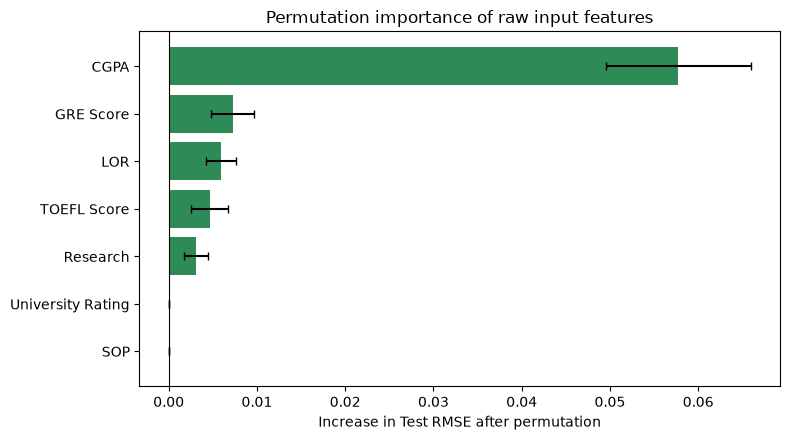

In [6]:
permutation_result = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_df = pd.DataFrame(
    {
        "Feature": FEATURES,
        "Mean RMSE increase": permutation_result.importances_mean,
        "Std RMSE increase": permutation_result.importances_std,
    }
).sort_values("Mean RMSE increase", ascending=False)

print("Post-selection permutation importance on fixed Test predictions:")
display(permutation_df.round(6))

fig, ax = plt.subplots(figsize=(8, 4.5))
ordered = permutation_df.sort_values("Mean RMSE increase")
ax.barh(
    ordered["Feature"],
    ordered["Mean RMSE increase"],
    xerr=ordered["Std RMSE increase"],
    color="seagreen",
    capsize=3,
)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("Increase in Test RMSE after permutation")
ax.set_title("Permutation importance of raw input features")
fig.tight_layout()
plt.show()

## 📈 Learning Curve

The learning curve uses only `X_train` and `y_train` with the complete fixed
Pipeline. `learning_curve` clones that Pipeline internally, so each training-size
split learns preprocessing only from its corresponding training portion. RMSE is
the primary plotted metric because it is the project selection metric. MAE and R2
remain complementary metrics in the fixed Train, Outer CV and Test evaluation.

This diagnostic does not select, tune or modify the model.

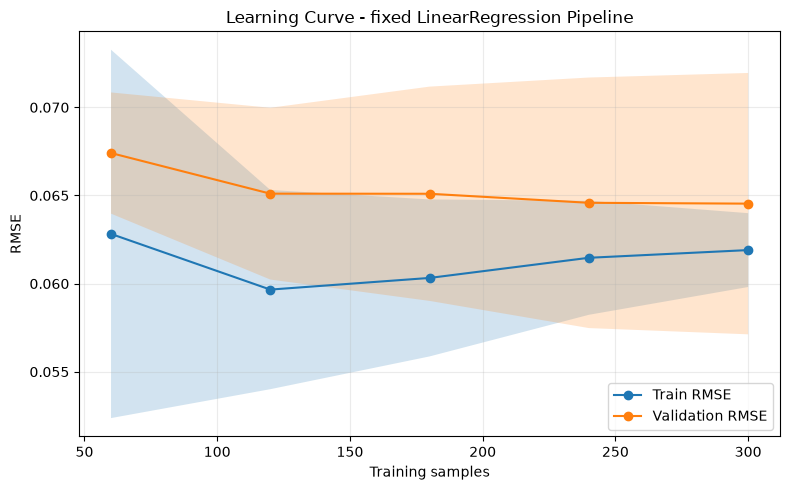

,Training size,Train RMSE mean,Train RMSE std,Validation RMSE mean,Validation RMSE std
0,60,0.062820,0.010449,0.067408,0.003438
1,120,0.059661,0.005651,0.065103,0.004873
2,180,0.060322,0.004453,0.065098,0.006079
3,240,0.061465,0.003234,0.064585,0.007107
4,300,0.061902,0.002094,0.064537,0.007414


Largest training size: 300
Largest-size Train RMSE: 0.061902
Largest-size validation RMSE: 0.064537
Largest-size validation minus Train RMSE: 0.002635
Interpretation: assess the gap, convergence and fold variability together; no universal threshold is imposed.


In [7]:
learning_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
(
    learning_sizes,
    learning_train_scores,
    learning_validation_scores,
    learning_fit_times,
    _learning_score_times,
) = learning_curve(
    final_pipeline,
    X_train,
    y_train,
    cv=learning_cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    shuffle=True,
    random_state=RANDOM_STATE,
    return_times=True,
    n_jobs=1,
    error_score="raise",
)

learning_train_rmse = -learning_train_scores
learning_validation_rmse = -learning_validation_scores
learning_curve_summary = pd.DataFrame(
    {
        "Training size": learning_sizes,
        "Train RMSE mean": learning_train_rmse.mean(axis=1),
        "Train RMSE std": learning_train_rmse.std(axis=1, ddof=1),
        "Validation RMSE mean": learning_validation_rmse.mean(axis=1),
        "Validation RMSE std": learning_validation_rmse.std(axis=1, ddof=1),
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    learning_sizes,
    learning_curve_summary["Train RMSE mean"],
    marker="o",
    label="Train RMSE",
)
ax.fill_between(
    learning_sizes,
    learning_curve_summary["Train RMSE mean"] - learning_curve_summary["Train RMSE std"],
    learning_curve_summary["Train RMSE mean"] + learning_curve_summary["Train RMSE std"],
    alpha=0.2,
)
ax.plot(
    learning_sizes,
    learning_curve_summary["Validation RMSE mean"],
    marker="o",
    label="Validation RMSE",
)
ax.fill_between(
    learning_sizes,
    learning_curve_summary["Validation RMSE mean"] - learning_curve_summary["Validation RMSE std"],
    learning_curve_summary["Validation RMSE mean"] + learning_curve_summary["Validation RMSE std"],
    alpha=0.2,
)
ax.set_title("Learning Curve - fixed LinearRegression Pipeline")
ax.set_xlabel("Training samples")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

display(learning_curve_summary.round(6))
largest_size = learning_curve_summary.iloc[-1]
largest_gap = largest_size["Validation RMSE mean"] - largest_size["Train RMSE mean"]
print(f"Largest training size: {int(largest_size['Training size'])}")
print(f"Largest-size Train RMSE: {largest_size['Train RMSE mean']:.6f}")
print(f"Largest-size validation RMSE: {largest_size['Validation RMSE mean']:.6f}")
print(f"Largest-size validation minus Train RMSE: {largest_gap:.6f}")
print(
    "Interpretation: assess the gap, convergence and fold variability together; no universal threshold is imposed."
)

In this run, the largest training size is 300 observations because each learning-curve
fold has a smaller training portion than the full 376-row Train set. At that size,
Train RMSE is 0.061902 and validation RMSE is 0.064537, a gap of 0.002635. The
validation RMSE decreases from 0.067408 at 60 observations to 0.064537 at 300,
with a near-flat trend after 120 observations. This is consistent with convergence
and limited additional improvement in the observed range, but it is not evidence
that more representative data could never help. The small gap does not suggest
strong high variance, and the close, moderate errors do not establish high bias.
Five-fold variability and the small dataset limit the strength of these conclusions.
MAE and R2 remain complementary fixed-evaluation metrics rather than additional
learning-curve scorers.

## ⏱️ Scalability Analysis

The following measurements come from the same deterministic, training-only
learning-curve execution. They show how Pipeline fit time and validation RMSE
change with training sample size. Test data is not used. These measurements describe
this small dataset only and are not production-scale performance evidence.

Scalability results are descriptive and cannot select, tune or modify the model.

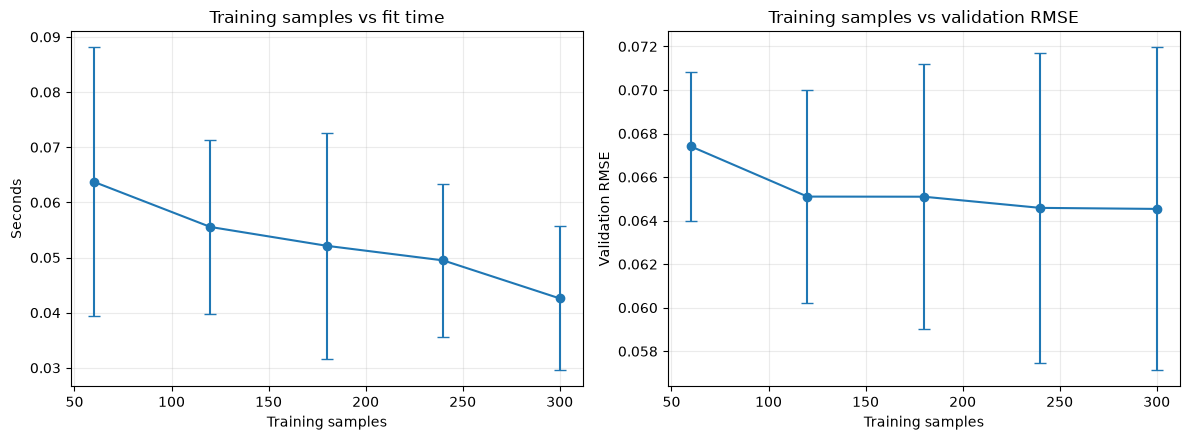

,Training samples,Fit time mean (s),Fit time std (s),Validation RMSE mean,Validation RMSE std
0,60,0.063722,0.024362,0.067408,0.003438
1,120,0.055546,0.015814,0.065103,0.004873
2,180,0.052127,0.020505,0.065098,0.006079
3,240,0.049482,0.013820,0.064585,0.007107
4,300,0.042593,0.013043,0.064537,0.007414


Fit times describe this local environment and small dataset; they are not production scalability guarantees.


In [8]:
scalability_summary = pd.DataFrame(
    {
        "Training samples": learning_sizes,
        "Fit time mean (s)": learning_fit_times.mean(axis=1),
        "Fit time std (s)": learning_fit_times.std(axis=1, ddof=1),
        "Validation RMSE mean": learning_validation_rmse.mean(axis=1),
        "Validation RMSE std": learning_validation_rmse.std(axis=1, ddof=1),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].errorbar(
    scalability_summary["Training samples"],
    scalability_summary["Fit time mean (s)"],
    yerr=scalability_summary["Fit time std (s)"],
    marker="o",
    capsize=4,
)
axes[0].set_title("Training samples vs fit time")
axes[0].set_xlabel("Training samples")
axes[0].set_ylabel("Seconds")
axes[0].grid(alpha=0.25)
axes[1].errorbar(
    scalability_summary["Training samples"],
    scalability_summary["Validation RMSE mean"],
    yerr=scalability_summary["Validation RMSE std"],
    marker="o",
    capsize=4,
)
axes[1].set_title("Training samples vs validation RMSE")
axes[1].set_xlabel("Training samples")
axes[1].set_ylabel("Validation RMSE")
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

display(scalability_summary.round(6))
print(
    "Fit times describe this local environment and small dataset; they are not production scalability guarantees."
)

In the observed range, validation RMSE decreases from 0.067408 to 0.064537 and
then changes only slightly. Fit-time means vary between approximately 0.0268 and
0.0309 seconds rather than increasing monotonically, so timing noise dominates any
strong scalability conclusion for this small dataset. These measurements describe
the local run only and do not support production-scale performance claims.

## 🔎 Error Analysis

This section analyzes predictions from the fixed Pipeline on the existing Test
split. It is post-selection diagnostic analysis only. No observation is removed,
no outlier treatment is applied and no model decision is made from these results.

### A. Residuals

Residuals are defined as `actual target - predicted target`. A positive residual
means underprediction; a negative residual means overprediction. The table and
plots report bias, error magnitude and the spread of errors.

### B. Largest prediction errors

The largest absolute errors are displayed with their original predictor values.
They are diagnostic cases only and are not removed or used to modify the model.

Residual statistics:


,Mean residual,Median residual,MAE,RMSE,Maximum absolute error,P50 absolute error,P90 absolute error,P95 absolute error,P99 absolute error
Fixed Test predictions,-0.001458,0.012471,0.051192,0.0685,0.26624,0.040383,0.107612,0.139958,0.181097


Underprediction fraction (positive residual): 0.579
Overprediction fraction (negative residual): 0.421


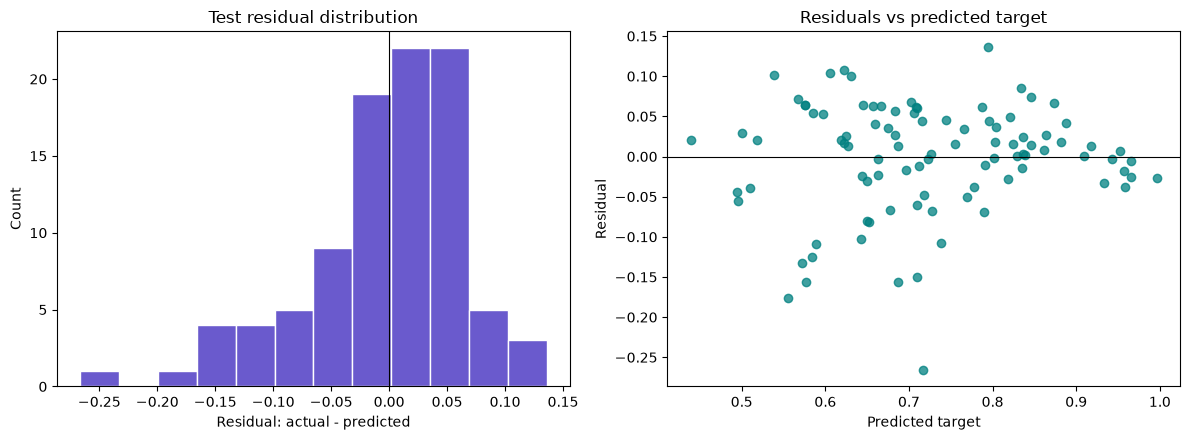

Ten largest absolute Test errors:


,GRE Score,TOEFL Score,CGPA,University Rating,SOP,LOR,Research,Actual target,Predicted target,Residual,Absolute error
9,323,108,8.60,3,3.5,3.0,0,0.45,0.7162,-0.2662,0.2662
412,299,<NA>,7.66,3,5.0,NaN,0,0.38,0.5557,-0.1757,0.1757
414,304,<NA>,7.84,4,NaN,2.5,0,0.42,0.5768,-0.1568,0.1568
42,313,107,8.50,2,2.5,2.0,1,0.53,0.6864,-0.1564,0.1564
63,315,107,8.50,2,4.0,3.0,1,0.56,0.7098,-0.1498,0.1498
440,331,115,NaN,5,NaN,3.5,1,0.93,0.7943,0.1357,0.1357
93,301,97,7.88,2,3.0,3.0,1,0.44,0.5727,-0.1327,0.1327
386,302,101,7.96,2,2.5,3.5,0,0.46,0.5846,-0.1246,0.1246
39,307,108,7.70,2,4.0,3.5,0,0.48,0.5893,-0.1093,0.1093
18,318,110,8.80,3,4.0,3.0,0,0.63,0.7379,-0.1079,0.1079


In [9]:
test_residuals = y_test.to_numpy() - test_predictions
test_absolute_errors = np.abs(test_residuals)
residual_stats = pd.DataFrame(
    {
        "Mean residual": [test_residuals.mean()],
        "Median residual": [np.median(test_residuals)],
        "MAE": [mean_absolute_error(y_test, test_predictions)],
        "RMSE": [root_mean_squared_error(y_test, test_predictions)],
        "Maximum absolute error": [test_absolute_errors.max()],
        "P50 absolute error": [np.percentile(test_absolute_errors, 50)],
        "P90 absolute error": [np.percentile(test_absolute_errors, 90)],
        "P95 absolute error": [np.percentile(test_absolute_errors, 95)],
        "P99 absolute error": [np.percentile(test_absolute_errors, 99)],
    },
    index=["Fixed Test predictions"],
)

test_error_df = X_test.copy()
test_error_df["Actual target"] = y_test.to_numpy()
test_error_df["Predicted target"] = test_predictions
test_error_df["Residual"] = test_residuals
test_error_df["Absolute error"] = test_absolute_errors
largest_errors = test_error_df.sort_values("Absolute error", ascending=False)

print("Residual statistics:")
display(residual_stats.round(6))
print(f"Underprediction fraction (positive residual): {np.mean(test_residuals > 0):.3f}")
print(f"Overprediction fraction (negative residual): {np.mean(test_residuals < 0):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(test_residuals, bins=12, color="slateblue", edgecolor="white")
axes[0].axvline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Test residual distribution")
axes[0].set_xlabel("Residual: actual - predicted")
axes[0].set_ylabel("Count")
axes[1].scatter(test_predictions, test_residuals, alpha=0.75, color="teal")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Residuals vs predicted target")
axes[1].set_xlabel("Predicted target")
axes[1].set_ylabel("Residual")
fig.tight_layout()
plt.show()

error_columns = [*FEATURES, "Actual target", "Predicted target", "Residual", "Absolute error"]
print("Ten largest absolute Test errors:")
display(largest_errors[error_columns].head(10).round(4))

### C. Outliers

The largest Test error is an overprediction of approximately 0.266 for an actual
target of 0.45. The largest-error table does not show a consistent extreme-value
pattern: the cases include ordinary-range predictor values, low academic profiles
and several missing predictor values. The target and predictor ranges are shown in
the data-quality table below. This is insufficient evidence to attribute the errors
to outliers. Large residuals are prediction-error outliers, not automatically data
outliers, and no observations are removed.

### D. Class imbalance and target coverage

`Chance of Admit` is continuous, so classical classification class imbalance does
not apply. The target distribution is still inspected for sparse coverage. The
displayed bins show more observations in the middle ranges, especially 0.6-0.8,
than at the lower and upper ends. This uneven coverage can affect error quality at
the extremes, but it should not be called class imbalance.

### E. Data-entry and data-quality errors

The data-quality table documents missing values, duplicates and observed ranges.
The values remain within the documented domain ranges, while missing values and
duplicate records are known data-quality characteristics. There is not enough
evidence to claim that any specific prediction error was caused by a data-entry
mistake. RAW and intermediate data remain unchanged.

### F. Encoder and preprocessing effects

`University Rating`, `SOP` and `LOR` use `OrdinalEncoder` and are then standardized.
This preserves ordering but implicitly represents adjacent ordinal levels with equal
numeric spacing. That is a modeling assumption and a possible source of error if the
real spacing between levels is not equal; it is not evidence that the encoder caused
any observed residual. `Research` is binary and is imputed without standardization.
The approved preprocessing is not changed here.

### G. Multicollinearity

The training-only VIF values identify the GRE, TOEFL and CGPA block as the main
collinearity concern. Correlated predictors can make individual LinearRegression
coefficients less stable or less individually interpretable even when the combined
Pipeline predicts well. This limits feature-level conclusions but does not justify
removing features or changing the selected model.

### Residual interpretation

The fixed Test residual mean is approximately -0.001458, close to zero relative to
the RMSE, with 57.9% positive residuals and 42.1% negative residuals. This suggests
little aggregate bias, although individual overpredictions and underpredictions are
material. The P90 and P95 absolute errors are approximately 0.1076 and 0.1400, and
the maximum is 0.2662. The residual plot should be read as evidence about changing
spread; the 95-row Test set is too small to make a strong heteroscedasticity claim.

Original rows: 623; duplicate rows: 152; unique rows: 471
Data-quality summary:


,Missing values in original rows,Minimum unique value,Maximum unique value
GRE Score,11,290.0,340.0
TOEFL Score,19,92.0,120.0
CGPA,2,6.8,9.92
University Rating,6,1.0,5.0
SOP,16,1.0,5.0
LOR,8,1.0,5.0
Research,29,0.0,1.0
Chance of Admit,0,0.34,0.97


Target coverage across unique observations:


,Observations
Chance of Admit,
"(0.299, 0.5]",42
"(0.5, 0.6]",45
"(0.6, 0.7]",110
"(0.7, 0.8]",135
"(0.8, 0.9]",80
"(0.9, 1.0]",59


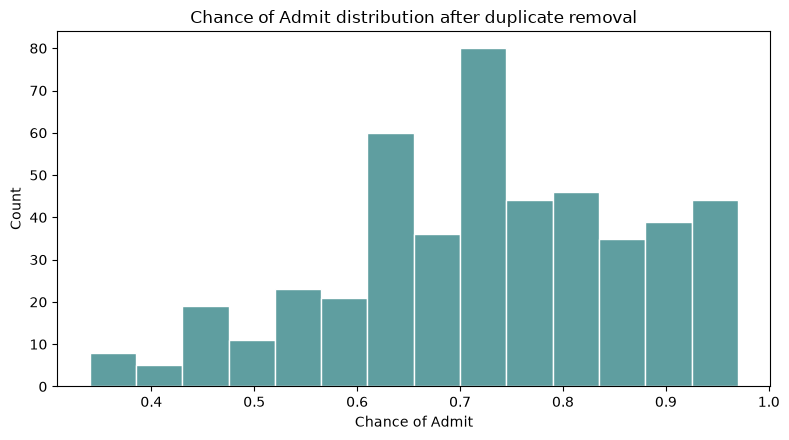

In [10]:
quality_columns = [*FEATURES, TARGET]
quality_df = pd.DataFrame(
    {
        "Missing values in original rows": admission_df[quality_columns].isna().sum(),
        "Minimum unique value": unique_df[quality_columns].min(numeric_only=True),
        "Maximum unique value": unique_df[quality_columns].max(numeric_only=True),
    }
)
target_bins = pd.cut(
    unique_df[TARGET],
    bins=[0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True,
)
target_distribution = target_bins.value_counts().sort_index().rename("Observations")

print(
    f"Original rows: {initial_rows}; duplicate rows: {duplicate_rows}; unique rows: {len(unique_df)}"
)
print("Data-quality summary:")
display(quality_df.round(4))
print("Target coverage across unique observations:")
display(target_distribution.to_frame())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(unique_df[TARGET], bins=14, color="cadetblue", edgecolor="white")
ax.set_title("Chance of Admit distribution after duplicate removal")
ax.set_xlabel("Chance of Admit")
ax.set_ylabel("Count")
fig.tight_layout()
plt.show()

### Consequences of Prediction Errors

An overprediction makes an applicant's estimated admission probability appear higher
than the observed target in this evaluation, while an underprediction makes it appear
lower. Therefore, the predictions are useful as decision-support information only
when their error and uncertainty are considered. The model outputs an estimated
probability-like target value; it is not a guaranteed admission decision and does not
establish a causal effect for any predictor. The available project documentation does
not support stronger institutional, financial or legal claims.

### Comparison with previous EDA

The EDA found the strongest marginal target associations for CGPA, GRE and TOEFL,
positive ordinal trends for University Rating, SOP and LOR, and a positive
Research-group difference. The fitted model preserves positive signs for the
academic block and Research, while conditional coefficients for University Rating
and SOP are close to zero and SOP is slightly negative. This is not a contradiction:
marginal EDA associations and conditional regression coefficients answer different
questions, especially when predictors are correlated.

The historical EDA used the full dataset, including rows later assigned to Test, and
included duplicates in some descriptive conclusions. That limitation is retained
rather than silently rewritten. The Issue #7 model interpretation uses the
deduplicated Issue #6 split for model metrics and training-only diagnostics.

### Conclusions

- LinearRegression remains the fixed practical model selected in Issue #6.
- CGPA has the largest standardized coefficient magnitude among the six standardized features.
- Research is positive but is interpreted as a separate unscaled binary contrast.
- The GRE, TOEFL and CGPA block shows descriptive multicollinearity.
- Permutation results complement, but do not replace, coefficient interpretation.
- No result establishes a causal effect or justifies changing the model.

## Proposals and Ideas

- Preserve the complete serialized Pipeline for reproducible inference.
- Reassess coefficient and permutation stability when new representative data becomes available.
- Keep Ridge as a possible future regularized alternative if the feature set expands or collinearity increases.
- Evaluate interactions or alternative regularization only in a future modeling Issue.
- Do not interpret the current coefficients as causal effects or use this notebook to modify the model.

In [11]:
print("Recommendation: keep the existing LinearRegression Pipeline unchanged.")
print("Future work should assess interpretation stability with new representative data.")
print("Current VIF and permutation results are descriptive and do not trigger model changes.")

Recommendation: keep the existing LinearRegression Pipeline unchanged.
Future work should assess interpretation stability with new representative data.
Current VIF and permutation results are descriptive and do not trigger model changes.


## References

- `models/05_model_selection_pipeline.joblib`
- `notebooks/5-models/05.2-SCO_model_selection-2026_08_20.ipynb`
- `notebooks/3-analysis/03.2-SCO_bivariate_analysis-2026_08_19.ipynb`
- `notebooks/3-analysis/03.3-SCO_multivariate_analysis-2026_08_19.ipynb`
- `data/02_intermediate/Admission_Predict.parquet`
- `notebooks/notebook_template.ipynb`
- scikit-learn documentation: `Pipeline`, `ColumnTransformer`, `permutation_importance` and `LinearRegression`
- `AGENTS.md` project operating rules; not modified or included in this Issue